Stream started
Time: 0.0s | People detected: 0
Time: 1.1s | People detected: 0
Time: 2.2s | People detected: 0
Time: 3.3s | People detected: 0
Time: 4.4s | People detected: 0
Time: 5.4s | People detected: 0
Time: 6.5s | People detected: 0
Time: 7.6s | People detected: 0
Time: 8.7s | People detected: 0
Time: 9.7s | People detected: 0
Time: 10.8s | People detected: 0
Time: 11.9s | People detected: 0
Time: 13.0s | People detected: 0
Time: 14.0s | People detected: 0
Time: 15.1s | People detected: 0
Time: 16.2s | People detected: 0
Time: 17.3s | People detected: 0
Time: 18.4s | People detected: 0
Time: 19.4s | People detected: 0
Time: 20.5s | People detected: 0
Time: 21.6s | People detected: 0
Time: 22.7s | People detected: 0
Time: 23.8s | People detected: 0
Time: 24.8s | People detected: 0
Time: 25.9s | People detected: 0
Time: 27.0s | People detected: 1
Time: 28.1s | People detected: 0
Time: 29.2s | People detected: 1
Time: 30.2s | People detected: 1
Time: 31.3s | People detected: 1
Time:

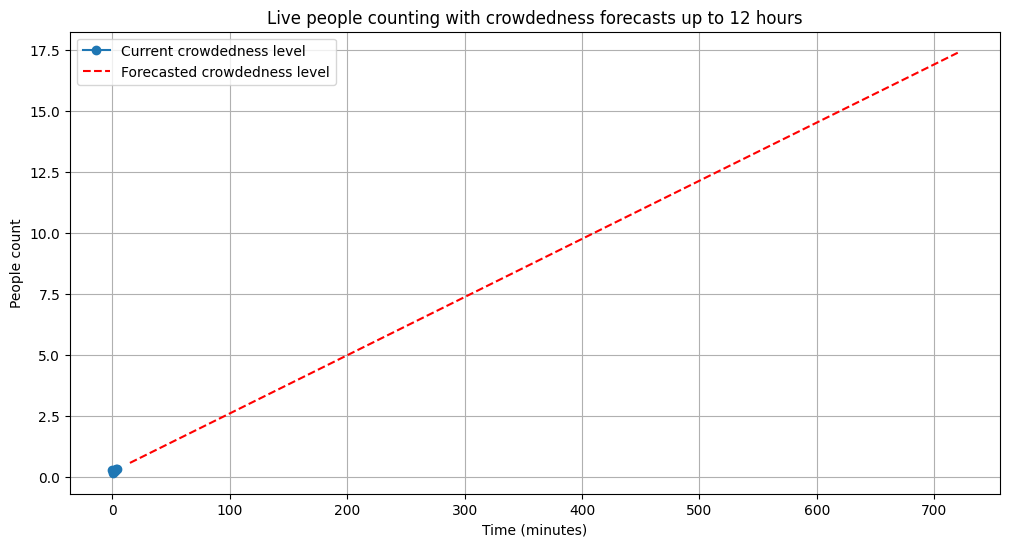

In [1]:
import sys
!{sys.executable} -m pip install ultralytics opencv-python-headless matplotlib pandas scikit-learn

from ultralytics import YOLO
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from sklearn.linear_model import LinearRegression
from pathlib import Path

# yolov8 instance segmentation model
model = YOLO("yolov8n-seg.pt")

# test stream
STREAM_URL = "https://test-streams.mux.dev/test_001/stream.m3u8"

TARGET_FPS = 1
MAX_RUNTIME = 300   # max seconds that model runs

# face blurring to ensure privacy
def blur_face(frame, mask):
    """
    Blurring the upper part of a person mask
    to comply with privacy (GDPR).
    """
    h, w = frame.shape[:2]
    mask = cv2.resize(mask, (w, h))

    ys, xs = np.where(mask > 0.5)
    if len(xs) == 0:
        return frame

    top = ys.min()
    bottom = top + int(0.3 * (ys.max() - top))  # upper 30%
    left, right = xs.min(), xs.max()

    roi = frame[top:bottom, left:right]
    roi = cv2.GaussianBlur(roi, (31, 31), 0)
    frame[top:bottom, left:right] = roi

    return frame

# detection of people in the stream
cap = cv2.VideoCapture(STREAM_URL)
if not cap.isOpened():
    raise Exception("Stream cannot be opened")

print("Stream started")

records = []
start_time = time.time()

while True:
    ret, frame = cap.read()
    if not ret or frame is None:
        time.sleep(1)
        continue

    elapsed = time.time() - start_time
    if elapsed > MAX_RUNTIME:
        break

    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # instance segmentation
    result = model.predict(
        frame_rgb,
        imgsz=640,
        conf=0.25,
        verbose=False
    )[0]

    people_count = 0
    annotated = frame_rgb.copy()

    if result.masks is not None:
        masks = result.masks.data.cpu().numpy()
        classes = result.boxes.cls.cpu().numpy().astype(int)

        for i, cls in enumerate(classes):
            if cls == 0:  # coco class 0 = person
                people_count += 1
                annotated = blur_face(annotated, masks[i])

    # logging raw data
    records.append({
        "time_s": elapsed,
        "people": people_count
    })

    print(f"Time: {elapsed:.1f}s | People detected: {people_count}")
    time.sleep(1 / TARGET_FPS)

cap.release()

# data handling part
df = pd.DataFrame(records)

# converting raw seconds to minutes
df["minute"] = (df["time_s"] // 60).astype(int)

# reducing noise through aggegration
df_min = df.groupby("minute").mean().reset_index()

# improving usability through smoothing
df_min["people_smooth"] = df_min["people"].rolling(
    window=3,
    min_periods=1
).mean()

# forecasting part
X = df_min["minute"].values.reshape(-1, 1)
y = df_min["people_smooth"].values

reg = LinearRegression()
reg.fit(X, y)

future_minutes = np.array([
    15,    # 15 minutes
    30,    # 30 minutes
    60,    # 1 hour
    180,   # 3 hours
    360,   # 6 hours
    720    # 12 hours
]).reshape(-1, 1)

future_preds = reg.predict(future_minutes)

df_forecast = pd.DataFrame({
    "minute": future_minutes.flatten(),
    "predicted_people": future_preds
})

# path to folders
DATA_DIR = Path("../data/new_data")
VIS_DIR = Path("../visualization/graphs")

# create folders if they don't exist
DATA_DIR.mkdir(parents=True, exist_ok=True)
VIS_DIR.mkdir(parents=True, exist_ok=True)

# outputs to folders
data_path = DATA_DIR / "people_count.csv"
df_min.to_csv(data_path, index=False)
print(f"Data saved in: {data_path.resolve()}")

forecast_path = DATA_DIR / "people_forecast.csv"
df_forecast.to_csv(forecast_path, index=False)
print(f"Forecast saved in: {forecast_path.resolve()}")

# visualization to folder
plt.figure(figsize=(12, 6))

plt.plot(
    df_min["minute"],
    df_min["people_smooth"],
    marker="o",
    label="Current crowdedness level"
)

plt.plot(
    df_forecast["minute"],
    df_forecast["predicted_people"],
    "--",
    color="red",
    label="Forecasted crowdedness level"
)

plt.xlabel("Time (minutes)")
plt.ylabel("People count")
plt.title("Live people counting with crowdedness forecasts up to 12 hours")
plt.legend()
plt.grid(True)

visual_path = VIS_DIR / "crowdedness_forecast.png"
plt.savefig(visual_path, bbox_inches="tight")
print(f"Visualization saved in: {visual_path.resolve()}")
plt.show()
